# 05 — Asymmetry: rockets and feathers

Does a \$1/gal crude increase reach the pump faster than a \$1/gal decrease?

This notebook fits the asymmetric distributed-lag model from `src/asymmetry.py`. The primary specification is the crude -> retail link with `K = 4`, selected in `04_lag_structure.ipynb` §5. §6b checks whether the result changes with `K = 6`, and §7 looks at all three links in the price chain to see where the asymmetry appears.

Here, `K` is the number of lags included in the model. A `lag` is a specific number of weeks after the crude price move: for example, `d_up_lag2` measures the retail response two weeks after a crude increase. From §5 onward, `h` is the cumulative horizon: the number of lags summed when measuring total pass-through, from 0 to `K`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.asymmetry import (
    DEFAULT_HAC_MAXLAGS,
    build_design_matrix,
    cumulative_passthrough,
    fit_distributed_lag,
    test_asymmetry,
)
from src.point_in_time import align_retail_to_upstream
from scripts.verify_alignment import PROCESSED_DIR, RETAIL_SERIES_ID, UPSTREAM_SERIES_ID, load_series

DAILY_CRUDE_SERIES_ID = "DCOILWTICO"
WHOLESALE_SERIES_ID = "WGASUSGULF"

K = 4  # crude → retail, chosen in 04_lag_structure.ipynb §5

COLOR_UP = "#eb6834"
COLOR_DOWN = "#2a78d6"
COLOR_RETAIL_LEVEL = "#1baf7a"
COLOR_CRUDE_LEVEL = "#4a3aa7"

retail_full = load_series(PROCESSED_DIR / "retail.csv", RETAIL_SERIES_ID, "weekly-mon")
weekly_crude = load_series(PROCESSED_DIR / "crude.csv", UPSTREAM_SERIES_ID, "weekly-fri")
daily_crude = load_series(PROCESSED_DIR / "crude.csv", DAILY_CRUDE_SERIES_ID, "daily").dropna(subset=["value"]).reset_index(drop=True)
wholesale_full = load_series(PROCESSED_DIR / "spot.csv", WHOLESALE_SERIES_ID, "weekly-fri")

# Same one-row trim as 04_lag_structure: daily crude's first usable close is 2010-01-04, so any
# weekly series starting on or before that has no valid daily_pit lookback for its first row.
# Applied here to every spec, not just the daily_pit ones, so all sections share one sample.
cutoff = daily_crude["date"].min()
retail = retail_full[retail_full["date"] > cutoff].reset_index(drop=True)
wholesale = wholesale_full[wholesale_full["date"] > cutoff].reset_index(drop=True)

# the aligned, undifferenced pair — used below to show actual price levels, not just diffs
merged = align_retail_to_upstream(retail, weekly_crude, mode="weekly")

X = build_design_matrix(retail, weekly_crude, K=K, mode="weekly")
res = fit_distributed_lag(X)

build_design_matrix: dropped 5 of 865 rows to NaN (differencing + 4 lag(s)); 860 rows remain


## 1. Design matrix

`build_design_matrix` aligns crude and retail by date using the no-look-ahead join from `src.point_in_time`, calculates the week-over-week change in each series, and splits the crude change into positive and negative parts. `d_up` is the positive change and `d_down` is the negative change. On each row, only one of them can be non-zero.

The model then creates lagged versions of both variables. `d_up_lag0` is the crude increase in the current week, `d_up_lag1` is the increase one week earlier, and so on through K. The same is done for decreases. This allows the regression to estimate a separate retail response to crude increases and decreases at each lag.

For example, retail on `2010-02-15` was \$2.608/gal, down from \$2.652 the week before, so
`d_retail` = -0.044 that week (first row below). The underlying crude price moved from \$1.775 to
\$1.759/gal (already converted to \$/gal), a \$0.016 decline, reflected as `d_down_lag0` = -0.016
and `d_up_lag0` = 0.

In [2]:
print(f"shape: {X.shape}")
with pd.option_context("display.float_format", "{:.4f}".format):
    display(X.head())

shape: (860, 12)


,date,d_retail,d_up_lag0,d_up_lag1,d_up_lag2,d_up_lag3,d_up_lag4,d_down_lag0,d_down_lag1,d_down_lag2,d_down_lag3,d_down_lag4
0,2010-02-15,-0.0440,0.0000,0.0150,0.0000,0.0000,0.0000,-0.0164,0.0000,-0.0638,-0.0819,-0.0543
1,2010-02-22,0.0470,0.1040,0.0000,0.0150,0.0000,0.0000,0.0000,-0.0164,0.0000,-0.0638,-0.0819
2,2010-03-01,0.0470,0.0231,0.1040,0.0000,0.0150,0.0000,0.0000,0.0000,-0.0164,0.0000,-0.0638
3,2010-03-08,0.0490,0.0231,0.0231,0.1040,0.0000,0.0150,0.0000,0.0000,0.0000,-0.0164,0.0000
4,2010-03-15,0.0370,0.0374,0.0231,0.0231,0.1040,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0164


The same five rows, shown with the underlying price levels:

In [3]:
merged.merge(X[["date"]], on="date")[["date", "value_retail", "upstream_date", "value_upstream"]].head()

,date,value_retail,upstream_date,value_upstream
0,2010-02-15,2.608,2010-02-12,1.759048
1,2010-02-22,2.655,2010-02-19,1.863095
2,2010-03-01,2.702,2010-02-26,1.886190
3,2010-03-08,2.751,2010-03-05,1.909286
4,2010-03-15,2.788,2010-03-12,1.946667


For scale, before turning to the differenced data: retail rose from \$2.751/gal in Jan 2010 to
\$4.079/gal in Aug 2026, a \$1.33/gal net increase. Crude ends near where it started (\$1.96 →
\$2.01/gal), despite the 2020 crash to near zero and the 2022 and 2026 spikes in between — the
path was far more volatile than the net change suggests.

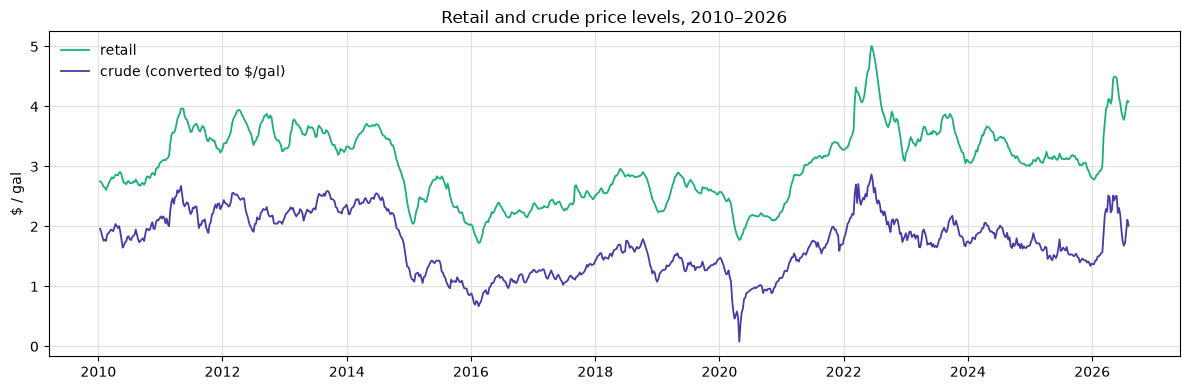

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(merged["date"], merged["value_retail"], color=COLOR_RETAIL_LEVEL, linewidth=1.3, label="retail")
ax.plot(merged["date"], merged["value_upstream"], color=COLOR_CRUDE_LEVEL, linewidth=1.3, label="crude (converted to $/gal)")
ax.set_title("Retail and crude price levels, 2010–2026")
ax.set_ylabel("$ / gal")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The chart below shows the actual regression input instead: week-over-week *change* (not level). The scale is smaller (roughly ±\$0.35/gal per week), since differencing removes the trend and leaves only the weekly moves.

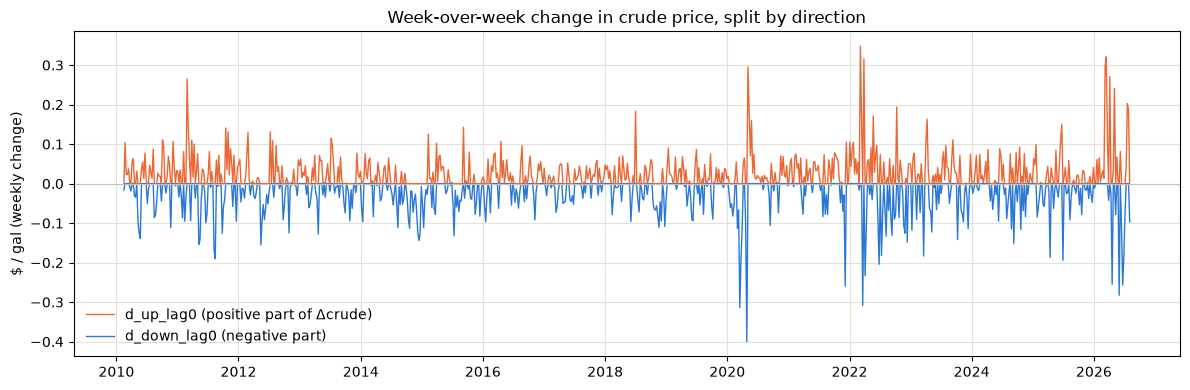

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(X["date"], X["d_up_lag0"], color=COLOR_UP, linewidth=1, label="d_up_lag0 (positive part of Δcrude)")
ax.plot(X["date"], X["d_down_lag0"], color=COLOR_DOWN, linewidth=1, label="d_down_lag0 (negative part)")
ax.axhline(0, color="#c3c2b7", linewidth=0.8)
ax.set_title("Week-over-week change in crude price, split by direction")
ax.set_ylabel("$ / gal (weekly change)")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 2. Regression

The model regresses `d_retail` on a constant and the up/down crude lags, using HAC (Newey–West)
standard errors instead of OLS's default ones. This is needed because the residuals are positively
autocorrelated (Durbin–Watson ≈ 1.19), so plain OLS standard errors would understate the true
uncertainty. `maxlags` defaults to 6, based on the standard rule of thumb for a sample of this
size (T ≈ 860). The HAC window is separate from K: `K` determines the regressors in the model,
while `maxlags` determines how far residual autocorrelation is allowed to affect the standard
errors. §6 checks whether this choice changes the results.

In [6]:
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               d_retail   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     29.78
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           2.37e-49
Time:                        18:08:53   Log-Likelihood:                 1486.7
No. Observations:                 860   AIC:                            -2951.
Df Residuals:                     849   BIC:                            -2899.
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0006      0.003      0.189      

The same-week coefficients differ substantially: 0.696 for `d_up_lag0` versus 0.263 for `d_down_lag0`.

The lag pattern also differs. The up-response falls quickly after the initial move (0.696, 0.138, 0.088, then close to zero). The down-response is slower: it is larger at lag 1 (0.338) than at lag 0 (0.263), then remains around 0.10–0.12 through lags 2–4. In other words, crude decreases reach retail more slowly and continue to pass through over several weeks.

R-squared is 0.50. Durbin–Watson is 1.19, indicating positive residual autocorrelation and supporting the use of HAC standard errors. Jarque–Bera rejects normality, with skewness of 1.21 and kurtosis of 9.68, indicating fat-tailed residuals. The condition number is 34.9, so there is no strong indication of problematic collinearity among the lagged regressors.

The same numbers, per lag rather than as a table. This is the shape that produces the cumulative gap in §4: where each direction's response sits in time, not just how large it is in total.

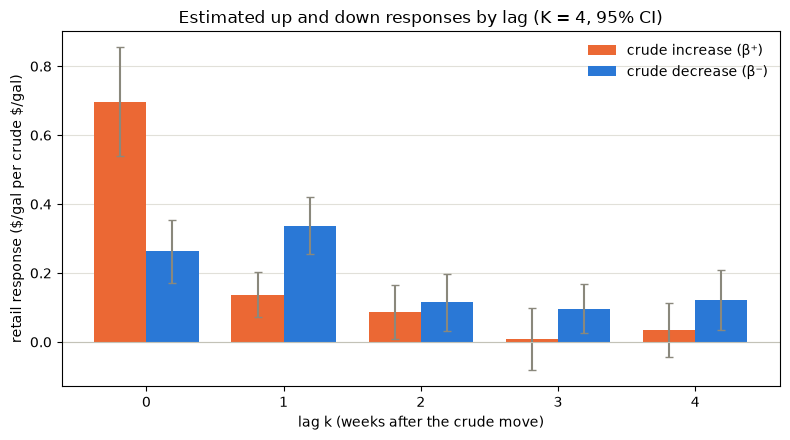

In [7]:
lags = list(range(K + 1))
up = [res.params[f"d_up_lag{k}"] for k in lags]
down = [res.params[f"d_down_lag{k}"] for k in lags]
up_err = [1.96 * res.bse[f"d_up_lag{k}"] for k in lags]
down_err = [1.96 * res.bse[f"d_down_lag{k}"] for k in lags]

fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.38
ax.bar([k - width / 2 for k in lags], up, width, color=COLOR_UP, label="crude increase (β⁺)", yerr=up_err, capsize=3, ecolor="#8a887c")
ax.bar([k + width / 2 for k in lags], down, width, color=COLOR_DOWN, label="crude decrease (β⁻)", yerr=down_err, capsize=3, ecolor="#8a887c")

ax.axhline(0, color="#c3c2b7", linewidth=0.8)
ax.set_xticks(lags)
ax.set_xlabel("lag k (weeks after the crude move)")
ax.set_ylabel(r"retail response (\$/gal per crude \$/gal)")
ax.set_title("Estimated up and down responses by lag (K = 4, 95% CI)")
ax.grid(True, axis="y", color="#e1e0d9")
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()

fig.savefig(REPO_ROOT / "assets" / "05_coefficients.png", dpi=110, bbox_inches="tight")
plt.show()

### 2b. Influence of extreme weeks

Some weeks have crude price changes several times larger than typical, so they can have a large influence on a regression based on Δcrude. We flag weeks with |Δcrude| ≥ $0.25/gal rather than selecting individual events by hand. This identifies 14 weeks, including the large 2020 and 2026 movements, the March 2022 spike, and two smaller extreme weeks in 2011 and 2021.

In [8]:
d_crude = X["d_up_lag0"] + X["d_down_lag0"]
is_extreme = d_crude.abs() >= 0.25

print(f"{is_extreme.sum()} extreme weeks dropped ({len(X)} -> {(~is_extreme).sum()} rows):")
display(X.loc[is_extreme, ["date"]].assign(d_crude=d_crude[is_extreme].round(3)).reset_index(drop=True))

res_trimmed = fit_distributed_lag(X.loc[~is_extreme].reset_index(drop=True))

cols = ["estimate", "ci_lo", "ci_hi", "p_value"]
full_vs_trimmed = pd.concat(
    {
        "full sample": pd.DataFrame([test_asymmetry(res, K=K, horizon=h) for h in (0, 1, K)]).set_index("horizon")[cols],
        "extremes dropped": pd.DataFrame([test_asymmetry(res_trimmed, K=K, horizon=h) for h in (0, 1, K)]).set_index("horizon")[cols],
    },
    axis=1,
)
full_vs_trimmed.round(4)

14 extreme weeks dropped (860 -> 846 rows):


,date,d_crude
0,2011-02-28,0.265
1,2020-03-16,-0.314
2,2020-04-27,-0.400
3,2020-05-04,0.295
4,2021-12-06,-0.260
5,2022-03-07,0.348
6,2022-03-21,-0.309
7,2022-03-28,0.316
8,2026-03-09,0.298
9,2026-03-16,0.321


full sample                         extremes dropped                  \
           estimate   ci_lo   ci_hi p_value         estimate   ci_lo   ci_hi   
horizon                                                                        
0            0.4333  0.2212  0.6454  0.0001           0.2639  0.0871  0.4407   
1            0.2331  0.0309  0.4353  0.0239           0.1446 -0.0639  0.3531   
4            0.0303 -0.2216  0.2822  0.8137           0.0728 -0.2568  0.4023   

                 
        p_value  
horizon          
0        0.0034  
1        0.1740  
4        0.6651

This is the one robustness check that materially changes the results. At h = 0, the gap falls from 0.433 to 0.264 but remains significant (p = 0.003). At h = 1, it falls from 0.233 to 0.145 and is no longer significant (p = 0.17, CI -0.064 to 0.353). At h = 4, both directions are already close to the same cumulative pass-through, so excluding these weeks makes little difference.

The same-week result therefore does not depend on the 14 extreme weeks. The week-1 result is less stable and is sensitive to their inclusion.

### 2c. Robustness: `daily_pit` alignment

The primary specification uses `mode="weekly"`, pairing each retail Monday with the prior Friday's weekly crude average. `daily_pit` instead uses the last daily crude close strictly before the retail date.

`04_lag_structure` §1 found that lag 0 and lag 1 are nearly tied under `daily_pit`, while the weekly alignment shows a sharper drop after lag 0. This suggests that the weekly averaging may place some of the response in lag 0 that appears in lag 1 under the daily point-in-time alignment.

In [9]:
X_pit = build_design_matrix(retail, daily_crude, K=K, mode="daily_pit")
res_pit = fit_distributed_lag(X_pit)

cols = ["estimate", "ci_lo", "ci_hi", "p_value"]
weekly_vs_pit = pd.concat(
    {
        "weekly": pd.DataFrame([test_asymmetry(res, K=K, horizon=h) for h in (0, 1, K)]).set_index("horizon")[cols],
        "daily_pit": pd.DataFrame([test_asymmetry(res_pit, K=K, horizon=h) for h in (0, 1, K)]).set_index("horizon")[cols],
    },
    axis=1,
)
weekly_vs_pit.round(4)

build_design_matrix: dropped 5 of 865 rows to NaN (differencing + 4 lag(s)); 860 rows remain


weekly                         daily_pit                        
        estimate   ci_lo   ci_hi p_value  estimate   ci_lo   ci_hi p_value
horizon                                                                   
0         0.4333  0.2212  0.6454  0.0001    0.2763  0.0705  0.4821  0.0085
1         0.2331  0.0309  0.4353  0.0239    0.2715  0.0391  0.5038  0.0220
4         0.0303 -0.2216  0.2822  0.8137    0.0689 -0.2143  0.3521  0.6336

Under `daily_pit`, the h = 0 gap falls from 0.433 to 0.276, while the h = 1 gap rises from 0.233 to 0.272. The overall pattern is similar, but the asymmetry is distributed more evenly across the first two weeks. Both gaps remain significant (p = 0.009 and p = 0.022), while the difference has disappeared by h = 4.

The main conclusion is therefore unchanged: the gap is concentrated in the first few weeks and closes over time. The exact split between week 0 and week 1 depends on the alignment method.

## 3. Residuals

Residuals are plotted over time, because the main features of interest here, serial correlation and changes in volatility, are easier to see in date order.

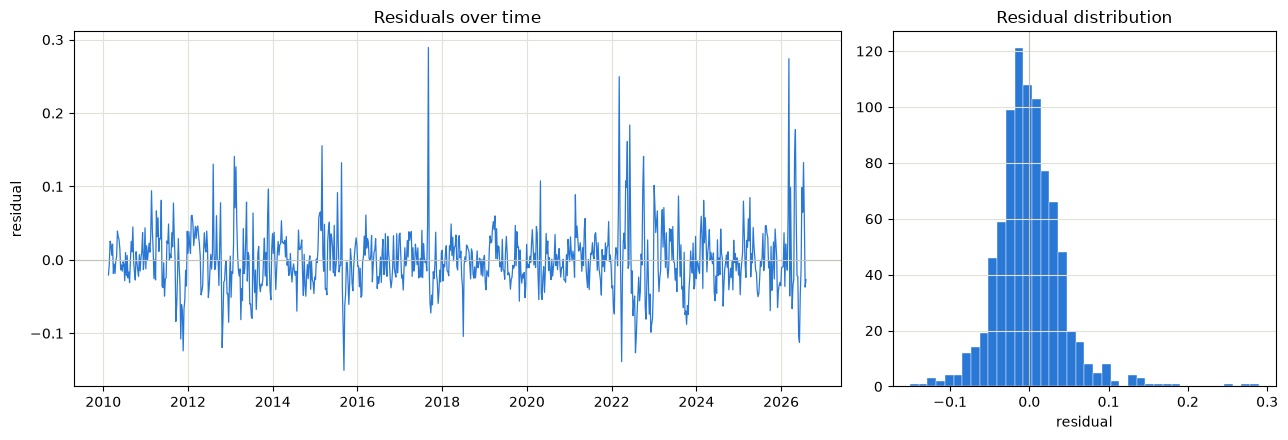

In [10]:
fig, (ax_time, ax_hist) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 1]})

ax_time.plot(X["date"], res.resid, color=COLOR_DOWN, linewidth=0.9)
ax_time.axhline(0, color="#c3c2b7", linewidth=0.8)
ax_time.set_ylabel("residual")
ax_time.set_title("Residuals over time")
ax_time.grid(True, color="#e1e0d9")

ax_hist.hist(res.resid, bins=40, color=COLOR_DOWN, edgecolor="#fcfcfb", linewidth=0.3)
ax_hist.axvline(0, color="#c3c2b7", linewidth=0.8)
ax_hist.set_xlabel("residual")
ax_hist.set_title("Residual distribution")
ax_hist.grid(True, axis="y", color="#e1e0d9")

plt.tight_layout()
plt.show()

Residuals remain centered around zero, with no obvious trend or level shift. The spread is fairly stable, apart from a few isolated spikes in 2017, 2022, and 2026 and a noisier period around 2022.

The 2020 weeks flagged in §2b are not unusually large residuals. They are influential because the crude price changes themselves are unusually large, while the model fits those observations relatively well.

The histogram is right-skewed with a long right tail, consistent with the Jarque–Bera result.

## 4. Cumulative pass-through

`cum_up(h)` sums the up-response coefficients from lag 0 through h. It represents the share of a \$1/gal crude increase that has reached retail by week h.`cum_down(h)` gives the equivalent measure for a crude decrease.

Confidence intervals are calculated using the full coefficient covariance matrix from `res.t_test`. This accounts for covariance between the lagged coefficients rather than treating their standard errors as independent.

The x-axis is the number of weeks after a single crude price move, not calendar time. The chart therefore shows how one crude price change passes through to retail over the following weeks.

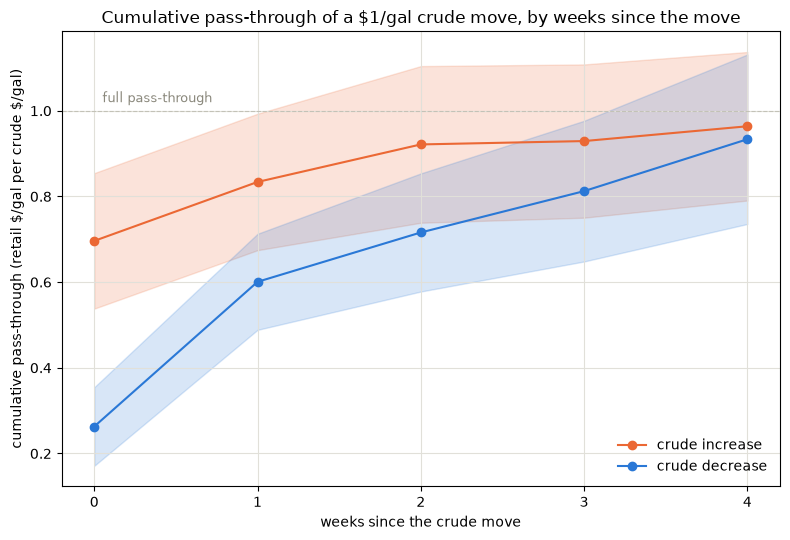

In [11]:
cp = cumulative_passthrough(res, K=K)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(cp["horizon"], cp["cum_up"], color=COLOR_UP, marker="o", label="crude increase")
ax.fill_between(cp["horizon"], cp["cum_up_lo"], cp["cum_up_hi"], color=COLOR_UP, alpha=0.18)

ax.plot(cp["horizon"], cp["cum_down"], color=COLOR_DOWN, marker="o", label="crude decrease")
ax.fill_between(cp["horizon"], cp["cum_down_lo"], cp["cum_down_hi"], color=COLOR_DOWN, alpha=0.18)

ax.axhline(1.0, color="#c3c2b7", linewidth=0.8, linestyle="--")
ax.annotate("full pass-through", xy=(0, 1.0), xytext=(0.05, 1.02), color="#8a887c", fontsize=9)
ax.set_title("Cumulative pass-through of a $1/gal crude move, by weeks since the move")
ax.set_xlabel("weeks since the crude move")
ax.set_ylabel(r"cumulative pass-through (retail \$/gal per crude \$/gal)")
ax.set_xticks(cp["horizon"])
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
cp.round(4)

,horizon,cum_up,cum_up_se,cum_up_lo,cum_up_hi,cum_down,cum_down_se,cum_down_lo,cum_down_hi
0,0,0.6963,0.0807,0.5381,0.8544,0.2629,0.0468,0.1712,0.3546
1,1,0.8338,0.0813,0.6746,0.9931,0.6007,0.0572,0.4886,0.7129
2,2,0.9214,0.0933,0.7386,1.1043,0.7159,0.0703,0.5781,0.8538
3,3,0.9293,0.0913,0.7504,1.1082,0.8124,0.0838,0.6482,0.9767
4,4,0.9638,0.0884,0.7905,1.1371,0.9335,0.1009,0.7357,1.1314


Up and down start far apart at h = 0 (0.70 vs. 0.26), then converge by h = 4 (0.96 vs.
0.93), both approaching full pass-through. The gap is timing, not the eventual total.

## 5. Significance of the asymmetry

`test_asymmetry` is run at every horizon from 0 to K, producing the estimate, 95% CI, and p-value
for (cumulative up) minus (cumulative down) through that horizon.

In [13]:
asymmetry_by_horizon = pd.DataFrame([test_asymmetry(res, K=K, horizon=h) for h in range(K + 1)])
asymmetry_by_horizon.round(4)

,horizon,estimate,se,ci_lo,ci_hi,p_value
0,0,0.4333,0.1082,0.2212,0.6454,0.0001
1,1,0.2331,0.1032,0.0309,0.4353,0.0239
2,2,0.2055,0.1183,-0.0263,0.4374,0.0823
3,3,0.1169,0.1269,-0.1318,0.3655,0.3570
4,4,0.0303,0.1285,-0.2216,0.2822,0.8137


The difference is significant at h = 0 (0.433, p = 0.0001) and h = 1 (0.233, p = 0.024). From h = 2 onward, the confidence interval includes zero (0.206, p = 0.082), and by h = 4 the difference is close to zero (0.030, p = 0.81).

The main result is therefore a short-run timing difference: crude increases pass through to retail faster than decreases. By h = 4, there is no evidence of a difference in cumulative pass-through.

## 6. Sensitivity to `maxlags`

This section addresses the HAC window, not the model specification. It affects only the standard
errors, so the point estimates below are identical across rows. What can change is the width of
the CI and whether it crosses zero.

In [14]:
rows = []
for maxlags in (3, DEFAULT_HAC_MAXLAGS, 12):
    res_alt = fit_distributed_lag(X, maxlags=maxlags)
    for h in (0, 1, K):
        rows.append({"maxlags": maxlags, **test_asymmetry(res_alt, K=K, horizon=h)})

pd.DataFrame(rows).round(4)

,maxlags,horizon,estimate,se,ci_lo,ci_hi,p_value
0,3,0,0.4333,0.1225,0.1933,0.6734,0.0004
1,3,1,0.2331,0.1162,0.0053,0.4609,0.0449
2,3,4,0.0303,0.1520,-0.2677,0.3283,0.8421
3,6,0,0.4333,0.1082,0.2212,0.6454,0.0001
4,6,1,0.2331,0.1032,0.0309,0.4353,0.0239
5,6,4,0.0303,0.1285,-0.2216,0.2822,0.8137
6,12,0,0.4333,0.0965,0.2442,0.6225,0.0000
7,12,1,0.2331,0.0982,0.0407,0.4255,0.0176
8,12,4,0.0303,0.1179,-0.2009,0.2614,0.7974


The h = 0 and h = 4 results are stable across all three HAC windows. The h = 1 result remains significant, but becomes marginal at `maxlags=3` (p = 0.045, with a CI lower bound of 0.005). This is another indication that the week-1 estimate is less stable than the same-week result.

### 6b. Sensitivity to the number of lags

The primary model uses `K = 4`, selected in `04_lag_structure` §5. Here we refit the model with `K = 6` to check whether the result depends on the choice of lag length.

In [15]:
res_k6 = fit_distributed_lag(build_design_matrix(retail, weekly_crude, K=6, mode="weekly"))

k_sensitivity = pd.DataFrame(
    [{"K": 4, **test_asymmetry(res, K=4, horizon=h)} for h in (0, 1, 4)]
    + [{"K": 6, **test_asymmetry(res_k6, K=6, horizon=h)} for h in (0, 1, 6)]
)
k_sensitivity.round(4)

build_design_matrix: dropped 7 of 865 rows to NaN (differencing + 6 lag(s)); 858 rows remain


,K,horizon,estimate,se,ci_lo,ci_hi,p_value
0,4,0,0.4333,0.1082,0.2212,0.6454,0.0001
1,4,1,0.2331,0.1032,0.0309,0.4353,0.0239
2,4,4,0.0303,0.1285,-0.2216,0.2822,0.8137
3,6,0,0.4419,0.1097,0.2269,0.6570,0.0001
4,6,1,0.2371,0.1042,0.0330,0.4413,0.0228
5,6,6,0.0640,0.1509,-0.2318,0.3598,0.6714


The pattern is essentially unchanged. The gap is significant at h = 0 (0.433 vs. 0.442) and h = 1 (0.233 vs. 0.237), with no meaningful difference remaining at the final horizon. Adding two lags changes the estimates by less than 0.01.

## 7. Where does the asymmetry occur?

The direct crude -> retail model shows that the two directions pass through at different speeds, but it cannot tell us where this difference arises. We therefore split the chain into crude -> wholesale and wholesale -> retail and estimate the same asymmetry test for each link.

Each link uses the lag length selected in `04_lag_structure` §5. We use the same HAC window across the three models.

For crude -> wholesale, we use daily crude with `mode="daily_pit"` because the weekly crude and wholesale observations share the same Friday date. This avoids pairing two observations from the same date when the crude observation may not have been available before the wholesale observation.

In [16]:
links = [
    ("crude → wholesale", wholesale, daily_crude, 1, "daily_pit"),
    ("wholesale → retail", retail, wholesale, 6, "weekly"),
    ("crude → retail", retail, weekly_crude, 4, "weekly"),
]

rows = []
for name, downstream, upstream, k, mode in links:
    link_res = fit_distributed_lag(
        build_design_matrix(downstream, upstream, K=k, mode=mode), maxlags=DEFAULT_HAC_MAXLAGS
    )
    for h in sorted({0, 1, k}):
        rows.append({"link": name, "K": k, **test_asymmetry(link_res, K=k, horizon=h)})

pd.DataFrame(rows).round(4)

build_design_matrix: dropped 2 of 865 rows to NaN (differencing + 1 lag(s)); 863 rows remain
build_design_matrix: dropped 7 of 865 rows to NaN (differencing + 6 lag(s)); 858 rows remain
build_design_matrix: dropped 5 of 865 rows to NaN (differencing + 4 lag(s)); 860 rows remain


,link,K,horizon,estimate,se,ci_lo,ci_hi,p_value
0,crude → wholesale,1,0,-0.0908,0.1172,-0.3204,0.1388,0.4382
1,crude → wholesale,1,1,0.0304,0.1657,-0.2943,0.3552,0.8544
2,wholesale → retail,6,0,0.3577,0.0770,0.2067,0.5087,0.0000
3,wholesale → retail,6,1,0.3396,0.0740,0.1947,0.4846,0.0000
4,wholesale → retail,6,6,-0.0597,0.0690,-0.1949,0.0756,0.3871
5,crude → retail,4,0,0.4333,0.1082,0.2212,0.6454,0.0001
6,crude → retail,4,1,0.2331,0.1032,0.0309,0.4353,0.0239
7,crude → retail,4,4,0.0303,0.1285,-0.2216,0.2822,0.8137


Crude -> wholesale shows no evidence of asymmetry at either early horizon (-0.091, p = 0.44 at h = 0; 0.030, p = 0.85 at h = 1).

Wholesale -> retail shows a clear short-run gap: 0.358 at h = 0 and 0.340 at h = 1, both p < 0.0001. By h = 6, the difference is no longer significant (-0.060, p = 0.39).

This suggests that the short-run asymmetry in the direct crude -> retail model arises mainly in the wholesale -> retail part of the chain, rather than in the crude → wholesale link.

## 8. Key Findings

The main result is a short-run rockets-and-feathers pattern: retail prices respond faster to crude price increases than to decreases, but the difference largely disappears over the following weeks.

**Primary result.** In the crude -> retail model with K = 4, a \$1/gal crude increase produces about \$0.70 of retail pass-through in the same week, compared with \$0.26 for a decrease. The gap is 0.433 (p = 0.0001). At h = 1, the gap is still significant at 0.233 (p = 0.024). By h = 4, cumulative pass-through is similar in both directions (0.96 vs. 0.93), with no significant difference remaining.

**Timing.** The lag coefficients show why the cumulative responses differ. The up-response is largest immediately and then falls quickly. The down-response is smaller at h = 0, peaks one week later, and continues through the following lags.

**Where it occurs.** When the chain is split, crude -> wholesale shows no evidence of asymmetry, while wholesale -> retail shows a strong short-run difference. This suggests that the asymmetry arises mainly between wholesale and retail rather than in the crude -> wholesale link.

**Robustness.** The same-week result remains significant after excluding the 14 extreme weeks and under `daily_pit` alignment, although the estimated gap becomes smaller. The h = 1 result is less stable: it loses significance after excluding extreme weeks and becomes marginal under a shorter HAC window. The choice of K has little effect on the results.

**Scope.** This is a differences-only model, so it does not address the long-run relationship between price levels. Cointegration and error correction are examined separately in the next stage. The analysis also uses the national average and does not address regional differences.